# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Uploading Files

In [2]:
#Uploading files from the folder

application=pd.read_csv(r"C:\Users\HP\Desktop\Courses Folder\Hero Python\Python Assingment\applications.csv", low_memory=False)
branches = pd.read_csv(r"C:\Users\HP\Desktop\Courses Folder\Hero Python\Python Assingment\branches.csv")
customers = pd.read_csv(r"C:\Users\HP\Desktop\Courses Folder\Hero Python\Python Assingment\customers.csv")
defaults = pd.read_csv(r"C:\Users\HP\Desktop\Courses Folder\Hero Python\Python Assingment\defaults.csv")
loans = pd.read_csv(r"C:\Users\HP\Desktop\Courses Folder\Hero Python\Python Assingment\loans.csv")
transactions = pd.read_csv(r"C:\Users\HP\Desktop\Courses Folder\Hero Python\Python Assingment\transactions.csv")

In [3]:
#Upaloding CSV files to Dataframe
Apps_df=pd.DataFrame(application)
Branch_df=pd.DataFrame(branches)
Customer_df=pd.DataFrame(customers)
Default_df=pd.DataFrame(defaults)
Loan_df=pd.DataFrame(loans)
Transaction_df=pd.DataFrame(transactions)

# 1. Data Quality and Preparation
 

In [4]:
#Formatting Dates
Apps_df['Application_Date'] = pd.to_datetime(Apps_df['Application_Date'], errors='coerce')
Transaction_df['Transaction_Date'] = pd.to_datetime(Transaction_df['Transaction_Date'], errors='coerce')
Default_df['Default_Date'] = pd.to_datetime(Default_df['Default_Date'], errors='coerce')

C:\Users\HP\AppData\Local\Temp\ipykernel_13444\2588641450.py:4: UserWarning: Parsing '20-07-2022' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  Default_df['Default_Date'] = pd.to_datetime(Default_df['Default_Date'], errors='coerce')
C:\Users\HP\AppData\Local\Temp\ipykernel_13444\2588641450.py:4: UserWarning: Parsing '23-09-2023' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  Default_df['Default_Date'] = pd.to_datetime(Default_df['Default_Date'], errors='coerce')
C:\Users\HP\AppData\Local\Temp\ipykernel_13444\2588641450.py:4: UserWarning: Parsing '16-10-2021' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  Default_df['Default_Date'] = pd.to_datetime(Default_df['Default_Date'], errors='coerce')
C:\Users\HP\AppData\Local\Temp\ipykernel_13444\2588641450.py:4: UserWarning: Parsing '27-04-2021' in DD/MM/YYYY format. Provide format o

In [5]:
Apps_df=Apps_df.fillna(0)
Branch_df=Branch_df.fillna(0)
Customer_df=Customer_df.fillna(0)
Default_df=Default_df.fillna(0)
Loan_df=Loan_df.fillna(0)
Transaction_df=Transaction_df.fillna(0)

In [6]:
Apps_df=Apps_df.drop_duplicates()
Branch_df=Branch_df.drop_duplicates()
Customer_df=Customer_df.drop_duplicates()
Default_df=Default_df.drop_duplicates()
Loan_df=Loan_df.drop_duplicates()
Transaction_df=Transaction_df.drop_duplicates()

In [7]:
#HAndling Outliers
Q1 = Loan_df['Loan_Amount'].quantile(0.25)
Q3 = Loan_df['Loan_Amount'].quantile(0.75)

# IQR Calculation
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

Loans = Loan_df[(Loan_df['Loan_Amount'] >= lower_limit) & (Loan_df['Loan_Amount'] <= upper_limit)]

print(f"Lower Limit: {lower_limit}")
print(f"Upper Limit: {upper_limit}")


Lower Limit: -2438290.75
Upper Limit: 7465697.25


In [8]:
#Merging Data
merged_data=pd.merge(Apps_df,Loan_df,on='Customer_ID')
merged_data=pd.merge(merged_data,Customer_df,on='Customer_ID')
merged_data=pd.merge(merged_data,Default_df,on='Customer_ID')
merged_data=pd.merge(merged_data,Transaction_df,on='Loan_ID')
merged_data.drop_duplicates()
merged_data.head(3)



,Application_ID,Loan_ID_x,Customer_ID_x,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status,Rejection_Reason,...,Recovery_Amount,Legal_Action,Transaction_ID,Customer_ID_y,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment
0,A000019,L000019,C000019,2020-03-03,2023-10-05,Personal,Agent,5924,Approved,0,...,0,Yes,T00009727,C055991,2023-10-05,Penalty,3632,0,1594090,Cheque
1,A000019,L000019,C000019,2020-03-03,2023-10-05,Personal,Agent,5924,Approved,0,...,0,Yes,T00054907,C055991,2021-05-30,EMI,38079,855,1484311,Cheque
2,A000019,L000019,C000019,2020-03-03,2023-10-05,Personal,Agent,5924,Approved,0,...,0,Yes,T00060665,C055991,2023-06-29,Penalty,31260,0,1997008,NEFT


# 2. Descriptive Analysis

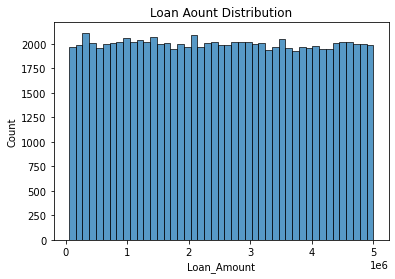

In [9]:
#DIstribution of Loan Amount
sns.histplot(Loan_df['Loan_Amount'])
plt.title('Loan Aount Distribution')
plt.show()

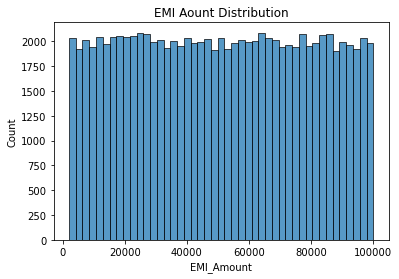

In [10]:
#DIstribution of EMI
sns.histplot(Loan_df['EMI_Amount'])
plt.title('EMI Aount Distribution')
plt.show()

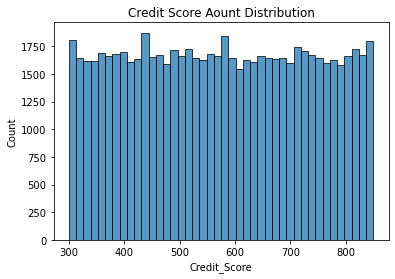

In [11]:
#DIstribution of Credit SScore
sns.histplot(Customer_df['Credit_Score'])
plt.title('Credit Score Aount Distribution')
plt.show()

In [13]:
merged_data_1=merged_data.drop(['Application_ID','Loan_ID_x'],axis=1)
merged_data_1=pd.DataFrame(merged_data_1)

In [14]:
#Regional Trend in Loan Disbursement and Default
New_Data=merged_data_1.groupby('Region')[['Loan_Amount','Default_Amount','Region']].sum()

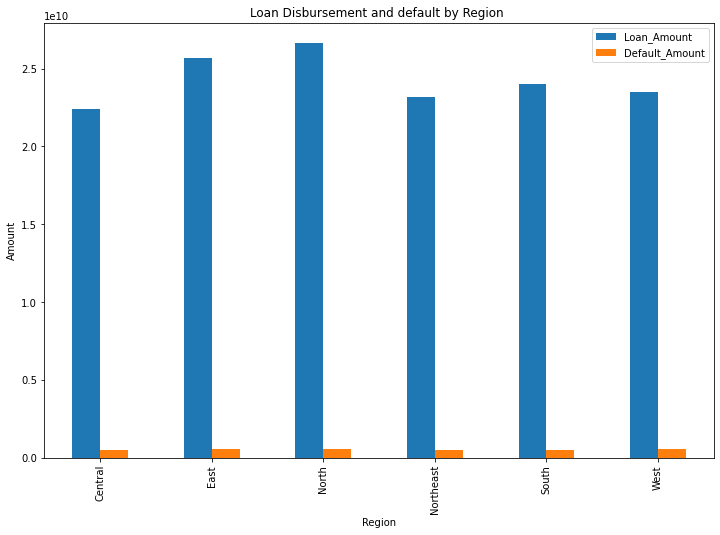

In [15]:
New_Data.plot(kind='bar',figsize=(12,8))
plt.title('Loan Disbursement and default by Region ')
plt.ylabel('Amount')
plt.show()

# Monthly trend in loan approval and disbursement

In [16]:
Apps_df['Approval_Date'] = pd.to_datetime(Apps_df['Approval_Date'], errors='coerce')
Loan_df['Disbursal_Date'] = pd.to_datetime(Loan_df['Disbursal_Date'], errors='coerce')

Approved = Apps_df[Apps_df['Approval_Status'] == 'Approved'].copy()

Approved['Month'] = Approved['Approval_Date'].dt.to_period('M')
Loan_df['Month'] = Loan_df['Disbursal_Date'].dt.to_period('M')

monthly_approvals = Approved.groupby('Month').size()

monthly_disbursement = Loan_df.groupby('Month')['Loan_Amount'].sum()


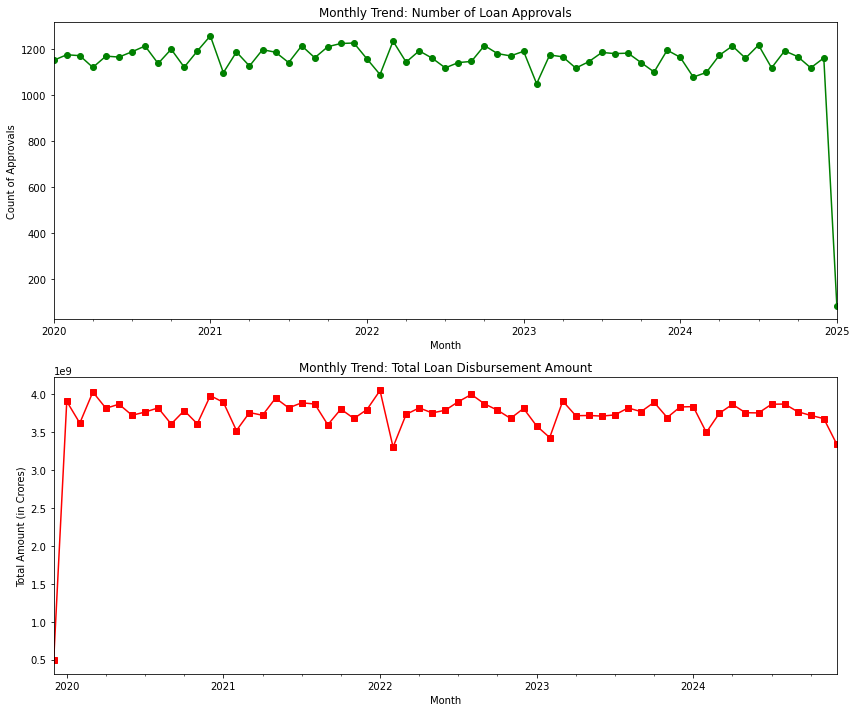

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1: Approvals Trend No of Loans
monthly_approvals.plot(kind='line', marker='o', color='green', ax=ax1)
ax1.set_title('Monthly Trend: Number of Loan Approvals')
ax1.set_ylabel('Count of Approvals')

# Chart 2: Loan Disbursed Amount?)
monthly_disbursement.plot(kind='line', marker='s', color='red', ax=ax2)
ax2.set_title('Monthly Trend: Total Loan Disbursement Amount')
ax2.set_ylabel('Total Amount (in Crores)')

plt.tight_layout()
plt.show()

# 3. Default RIsk Analysis

In [18]:
#Calculate correlations between Loan_Amount, Interest_Rate, Credit_Score, and Default_Flag (a binary indicator for default).


Loan_df['Default_Flag'] = Loan_df['Loan_ID'].isin(Default_df['Loan_ID']).astype(int)
Updated_merged_data = pd.merge(Loan_df, Customer_df[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')
Req_Col = ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']
correlation_matrix = Updated_merged_data[Req_Col].corr()
print("Correlation Table")
print(correlation_matrix)

print('Higher Interest Rates often have a positive correlation with defaults')
print('Higher the Credit Score, Lower the defaults')

Correlation Table
               Loan_Amount  Interest_Rate  Credit_Score  Default_Flag
Loan_Amount       1.000000      -0.003201      0.000139     -0.003313
Interest_Rate    -0.003201       1.000000      0.002457     -0.003750
Credit_Score      0.000139       0.002457      1.000000     -0.001580
Default_Flag     -0.003313      -0.003750     -0.001580      1.000000
Higher Interest Rates often have a positive correlation with defaults
Higher the Credit Score, Lower the defaults


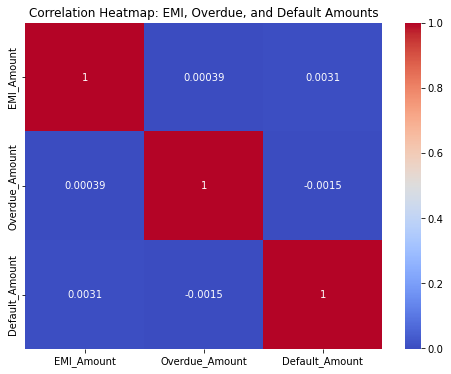

In [19]:
#Create a heatmap to visualize the correlations between key variables, such as EMI_Amount, Overdue_Amount, and Default_Amount
#Data merging

Updated_merged_data2 = pd.merge(Loan_df, Default_df[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')

#Filling in NA's

Updated_merged_data2['Default_Amount'] = Updated_merged_data2['Default_Amount'].fillna(0)

#Uploading columns in heatmap
data_for_heatmap = Updated_merged_data2[['EMI_Amount', 'Overdue_Amount', 'Default_Amount']]

#Correlation Calculation
corr_matrix = data_for_heatmap.corr()

#Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap: EMI, Overdue, and Default Amounts')
plt.show()

# 4. Branch & Regional Performance

In [20]:
Branch_Ranking=Branch_df.sort_values(by=['Loan_Disbursement_Amount'],ascending=False)
print("Top Branches:")
print(Branch_Ranking[['Branch_ID', 'Loan_Disbursement_Amount']])

Top Branches:
   Branch_ID  Loan_Disbursement_Amount
35      B036                 499562869
13      B014                 482327541
11      B012                 465469874
47      B048                 464419943
34      B035                 449109596
42      B043                 447832443
2       B003                 445787808
49      B050                 442594434
9       B010                 435407779
36      B037                 420746720
39      B040                 410883979
25      B026                 401253151
27      B028                 393550434
23      B024                 375279666
33      B034                 363032381
21      B022                 362728718
8       B009                 356643441
3       B004                 353934299
0       B001                 341680882
4       B005                 311637902
44      B045                 306018078
26      B027                 299774333
22      B023                 269375830
45      B046                 257206777
12      B01

In [21]:
#Processing Time Efficiency
Branch_Processing=Branch_df.sort_values(by=['Avg_Processing_Time'],ascending=True)
print("Top Processing Time:")
print(Branch_Processing[['Branch_ID', 'Avg_Processing_Time']])


Top Processing Time:
   Branch_ID  Avg_Processing_Time
49      B050                    1
46      B047                    2
41      B042                    2
17      B018                    2
44      B045                    3
26      B027                    3
11      B012                    3
47      B048                    4
32      B033                    5
22      B023                    5
43      B044                    6
40      B041                    6
37      B038                    6
20      B021                    6
0       B001                    6
13      B014                    7
12      B013                    7
6       B007                    7
7       B008                    7
24      B025                    8
1       B002                    8
3       B004                    9
28      B029                    9
16      B017                   10
39      B040                   10
9       B010                   10
33      B034                   10
45      B046               

In [53]:
#Default RAte and Recovery Rate

#1. Deafult RAte

Total_Loans=len(Loan_df)
Total_defaults=len(Default_df)

Default_Rate=(Total_defaults/Total_Loans)*100
print('The Loan default Rate is:', Default_Rate)

"""
#2. Recovery RAte
Loans_Recovered=Default_df[Default_df['Recovery_Status']=="Full"]
Loans_Recovered=Loans_Recovered.astype(int)

Recovery_Rate=(Loans_Recovered/Total_defaults)*100
print('The Loan Recovery Rate is:', Recovery_Rate)

"""



The Loan default Rate is: 10.0


'\n#2. Recovery RAte\nLoans_Recovered=Default_df[Default_df[\'Recovery_Status\']=="Full"]\nLoans_Recovered=Loans_Recovered.astype(int)\n\nRecovery_Rate=(Loans_Recovered/Total_defaults)*100\nprint(\'The Loan Recovery Rate is:\', Recovery_Rate)\n\n'

In [23]:
#● Compare branch performance across regions.


# 5. Customer Segmentation

In [24]:
# 1. ● Segment customers by income, credit score, and loan status.

New_merged_df = pd.merge(Customer_df, Loan_df[['Customer_ID', 'Loan_Status']], on='Customer_ID', how='inner')

def get_income_group(income):
    if income < 500000:
        return 'Low Income'
    elif income <= 1500000:
        return 'Medium Income'
    else:
        return 'High Income'

New_merged_df['Income_Segment'] = New_merged_df['Annual_Income'].apply(get_income_group)

In [25]:

def get_credit_group(score):
    if score < 600:
        return 'Poor Credit Rating'
    elif score <= 750:
        return 'Avg Credit Rating'
    else:
        return 'Good Credit Rating'


In [26]:
New_merged_df['Credit_Segment'] = New_merged_df['Credit_Score'].apply(get_credit_group)


segmentation_report = New_merged_df.groupby(['Income_Segment', 'Credit_Segment', 'Loan_Status']).size().reset_index(name='Customer_Count')

print(segmentation_report)

   Income_Segment      Credit_Segment Loan_Status  Customer_Count
0     High Income   Avg Credit Rating      Active            2252
1     High Income   Avg Credit Rating      Closed            2318
2     High Income   Avg Credit Rating     Overdue            2346
3     High Income  Good Credit Rating      Active            1461
4     High Income  Good Credit Rating      Closed            1448
5     High Income  Good Credit Rating     Overdue            1451
6     High Income  Poor Credit Rating      Active            4561
7     High Income  Poor Credit Rating      Closed            4552
8     High Income  Poor Credit Rating     Overdue            4586
9      Low Income   Avg Credit Rating      Active            1348
10     Low Income   Avg Credit Rating      Closed            1332
11     Low Income   Avg Credit Rating     Overdue            1350
12     Low Income  Good Credit Rating      Active             939
13     Low Income  Good Credit Rating      Closed             877
14     Low

In [27]:
# ● Identify high-risk and high-value customer groups.

Updated_merged_df3 = pd.merge(Customer_df, Loan_df[['Customer_ID', 'Loan_ID', 'Loan_Status']], on='Customer_ID', how='inner')

Updated_merged_df3['Default_Flag'] = Updated_merged_df3['Loan_ID'].isin(Default_df['Loan_ID']).astype(int)

def get_income_group(income):
    return 'High' if income > 1500000 else 'Medium' if income > 500000 else 'Low'

def get_credit_group(score):
    return 'Good' if score > 750 else 'Average' if score > 600 else 'Poor'

Updated_merged_df3['Income_Group'] = Updated_merged_df3['Annual_Income'].apply(get_income_group)
Updated_merged_df3['Credit_Group'] = Updated_merged_df3['Credit_Score'].apply(get_credit_group)

high_value = Updated_merged_df3[(Updated_merged_df3['Credit_Group'] == 'Good') &
                                (Updated_merged_df3['Income_Group'] == 'High') & 
                                (Updated_merged_df3['Default_Flag'] == 0)]

high_risk = Updated_merged_df3[(Updated_merged_df3['Credit_Group'] == 'Poor') & 
                               (Updated_merged_df3['Default_Flag'] == 1)]

print(f"Total High-Value Customers found: {len(high_value)}")
print(f"Total High-Risk Customers found: {len(high_risk)}")

Total High-Value Customers found: 3936
Total High-Risk Customers found: 4724


Repayment Behavior Summary:
  Income_Group Credit_Group  Default_Flag  Default_Rate_%
0         High      Average      0.087752        8.775243
1         High         Good      0.097248        9.724771
2         High         Poor      0.092994        9.299447
3          Low      Average      0.101355       10.135474
4          Low         Good      0.088290        8.829031
5          Low         Poor      0.097217        9.721720
6       Medium      Average      0.093023        9.302326
7       Medium         Good      0.098238        9.823760
8       Medium         Poor      0.096000        9.600000


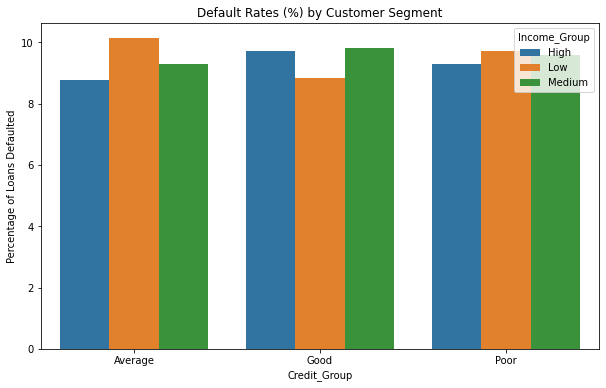

In [28]:
# 3. Repayment Analysis

master_df = pd.merge(Loan_df, Customer_df[['Customer_ID', 'Annual_Income', 'Credit_Score']], on='Customer_ID', how='left')

master_df['Income_Group'] = master_df['Annual_Income'].apply(lambda x: 'High' if x > 1500000 else 'Medium' if x > 500000 else 'Low')
master_df['Credit_Group'] = master_df['Credit_Score'].apply(lambda x: 'Good' if x > 750 else 'Average' if x > 600 else 'Poor')

repayment_report = master_df.groupby(['Income_Group', 'Credit_Group'])['Default_Flag'].mean().reset_index()

repayment_report['Default_Rate_%'] = repayment_report['Default_Flag'] * 100

print("Repayment Behavior Summary:")
print(repayment_report)

plt.figure(figsize=(10, 6))
sns.barplot(x='Credit_Group', y='Default_Rate_%', hue='Income_Group', data=repayment_report)

plt.title('Default Rates (%) by Customer Segment')
plt.ylabel('Percentage of Loans Defaulted')
plt.show()

# 6. Advanced Stat Analysis

In [29]:
#1. Corr Analysis for Default RIsk

#'Default_Flag' and 'Default_Amount'
# Mergining defaults into loans to see who actually failed to pay
Loan_default_merged = pd.merge(Loan_df, Default_df[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')
Loan_default_merged['Default_Flag'] = Loan_default_merged['Default_Amount'].notna().astype(int)

final_df = pd.merge(Loan_default_merged, Customer_df[['Customer_ID', 'Credit_Score']], on='Customer_ID', how='left')

stats_columns = [
    'Credit_Score', 
    'Loan_Amount', 
    'Interest_Rate', 
    'Overdue_Amount', 
    'Default_Flag'
]

# 5. Correlation Matrix calculation
correlation_matrix = final_df[stats_columns].corr()

print(" Advanced Correlation Matrix")
print(correlation_matrix)


 Advanced Correlation Matrix
                Credit_Score  Loan_Amount  Interest_Rate  Overdue_Amount  \
Credit_Score        1.000000     0.000262       0.002498        0.001990   
Loan_Amount         0.000262     1.000000      -0.003451        0.008249   
Interest_Rate       0.002498    -0.003451       1.000000       -0.002700   
Overdue_Amount      0.001990     0.008249      -0.002700        1.000000   
Default_Flag       -0.001724    -0.002401      -0.004763        0.000020   

                Default_Flag  
Credit_Score       -0.001724  
Loan_Amount        -0.002401  
Interest_Rate      -0.004763  
Overdue_Amount      0.000020  
Default_Flag        1.000000  


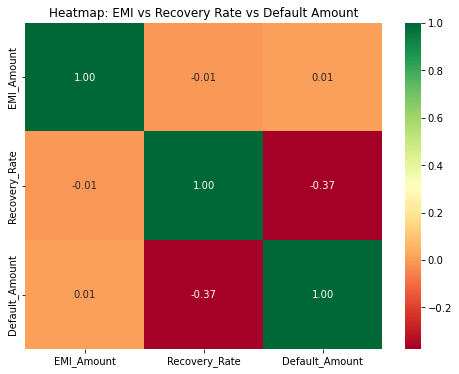

In [30]:
#2 Pairwise corr heatmap EMI, Recovery and Ddefault

merged_df3 = pd.merge(Loan_df[['Loan_ID', 'EMI_Amount']], 
                     Default_df[['Loan_ID', 'Default_Amount', 'Recovery_Amount']], 
                     on='Loan_ID', 
                     how='inner')

merged_df3['Recovery_Rate'] = merged_df3['Recovery_Amount'] / merged_df3['Default_Amount']

heatmap_data = merged_df3[['EMI_Amount', 'Recovery_Rate', 'Default_Amount']]

corr_matrix = heatmap_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")

plt.title('Heatmap: EMI vs Recovery Rate vs Default Amount')
plt.show()

In [31]:
#3 Branch level corr

# No common data

# 7. Transaction and Recovery Analysis

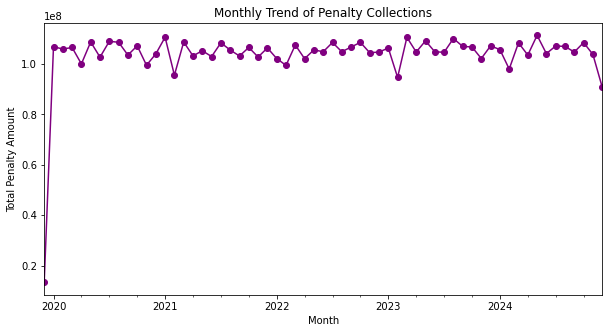

Total Money Currently Overdue: 1147125736


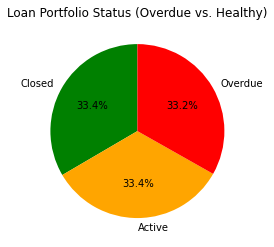

In [32]:
#● Analyze penalty payments and overdue trends.

#Filter for 'Penalty'.
penalty_data = Transaction_df[Transaction_df['Payment_Type'] == 'Penalty'].copy()

penalty_data['Month'] = penalty_data['Transaction_Date'].dt.to_period('M')

monthly_penalties = penalty_data.groupby('Month')['Amount'].sum()

monthly_penalties.plot(kind='line', marker='o', color='purple', figsize=(10, 5))
plt.title('Monthly Trend of Penalty Collections')
plt.ylabel('Total Penalty Amount')
plt.show()

status_counts = Loan_df['Loan_Status'].value_counts()

total_overdue_amt = Loan_df['Overdue_Amount'].sum()
print(f"Total Money Currently Overdue: {total_overdue_amt}")

status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['green', 'orange', 'red'])
plt.title('Loan Portfolio Status (Overdue vs. Healthy)')
plt.ylabel('')
plt.show()

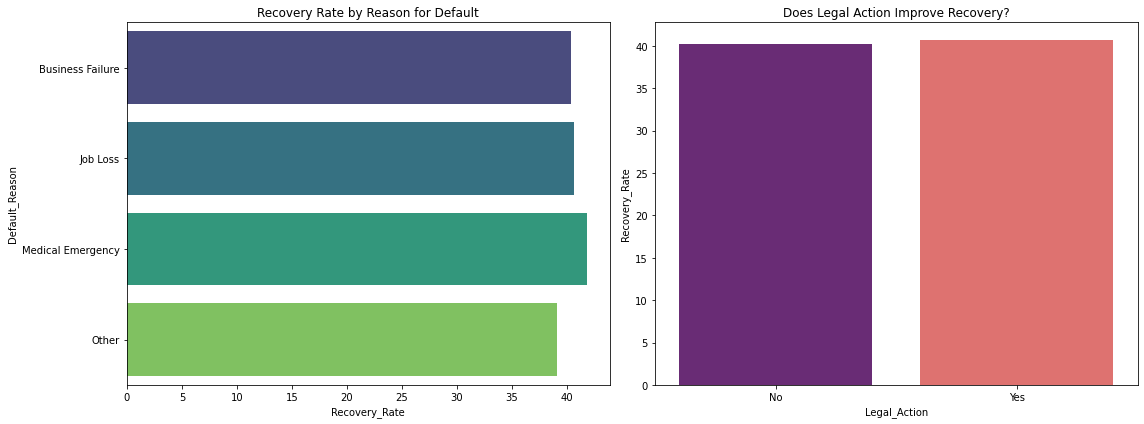

In [33]:
#● Evaluate recovery rates by Default_Reason and Legal_Action.

#Recovery Rate
Default_df['Recovery_Rate'] = (Default_df['Recovery_Amount'] / Default_df['Default_Amount']) * 100

reason_recovery = Default_df.groupby('Default_Reason')['Recovery_Rate'].mean().reset_index()

legal_recovery = Default_df.groupby('Legal_Action')['Recovery_Rate'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Recovery by Reason
sns.barplot(x='Recovery_Rate', y='Default_Reason', data=reason_recovery, ax=ax1, palette='viridis')
ax1.set_title('Recovery Rate by Reason for Default')

# Chart 2: Recovery by Legal Action
sns.barplot(x='Legal_Action', y='Recovery_Rate', data=legal_recovery, ax=ax2, palette='magma')
ax2.set_title('Does Legal Action Improve Recovery?')

plt.tight_layout()
plt.show()

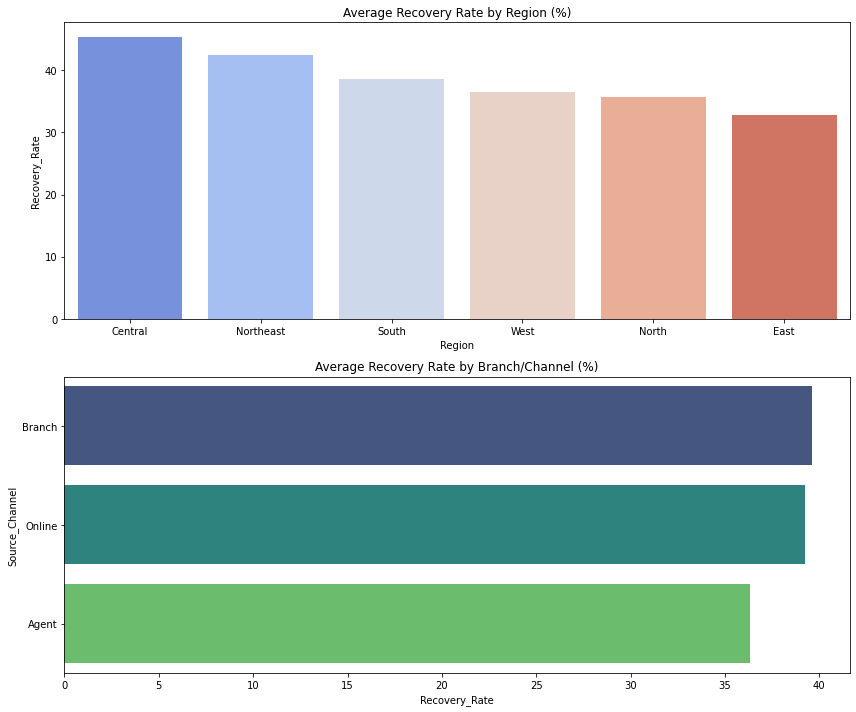

In [34]:
#● Compare recovery rates across regions and branches.

# Recovery Rate in the defaults table
Default_df['Recovery_Rate'] = (Default_df['Recovery_Amount'] / Default_df['Default_Amount']) * 100

recovery_Reg_df = pd.merge(Default_df, merged_data[['Loan_ID', 'Region', 'Source_Channel']], on='Loan_ID', how='left')

# Group by Region
region_recovery = recovery_Reg_df.groupby('Region')['Recovery_Rate'].mean().sort_values(ascending=False).reset_index()

# Group by Branch (Source_Channel in this dataset)
branch_recovery = recovery_Reg_df.groupby('Source_Channel')['Recovery_Rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 10))

# Chart 1: Regional Comparison
plt.subplot(2, 1, 1)
sns.barplot(x='Region', y='Recovery_Rate', data=region_recovery, palette='coolwarm')
plt.title('Average Recovery Rate by Region (%)')

# Chart 2: Branch Comparison
plt.subplot(2, 1, 2)
sns.barplot(x='Recovery_Rate', y='Source_Channel', data=branch_recovery, palette='viridis')
plt.title('Average Recovery Rate by Branch/Channel (%)')

plt.tight_layout()
plt.show()

# 8. EMI Analysis

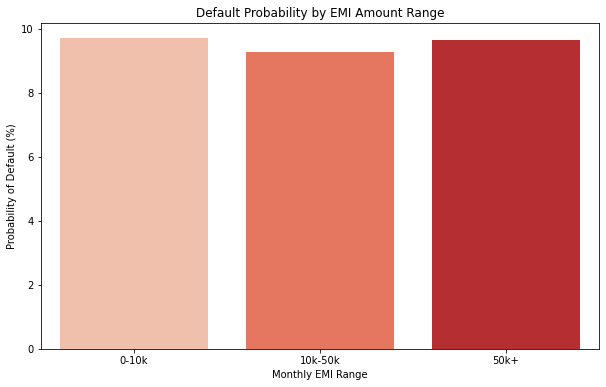

In [35]:
#1. Analyze the relationship between EMI amounts and default probabilities.

#Create the 'Default_Flag' 
Loan_df['Default_Flag'] = Loan_df['Loan_ID'].isin(Default_df['Loan_ID']).astype(int)

# 3. Create EMI Bins (Groups of 10,000 for example)
# This turns a specific number like 12,500 into a range like "10k - 20k"
bins = [0,10000,50000, 100000]
labels = ['0-10k', '10k-50k', '50k+']
Loan_df['EMI_Range'] = pd.cut(Loan_df['EMI_Amount'], bins=bins, labels=labels)

# 4. Calculate Default Probability (Mean of the flag)
# For example, if 10 out of 100 people in a range defaulted, the probability is 0.10 (10%)
emi_risk_analysis = Loan_df.groupby('EMI_Range')['Default_Flag'].mean().reset_index()
emi_risk_analysis['Default_Probability_%'] = emi_risk_analysis['Default_Flag'] * 100

# 5. Visualize the relationship
plt.figure(figsize=(10, 6))
sns.barplot(x='EMI_Range', y='Default_Probability_%', data=emi_risk_analysis, palette='Reds')

plt.title('Default Probability by EMI Amount Range')
plt.xlabel('Monthly EMI Range')
plt.ylabel('Probability of Default (%)')
plt.show()




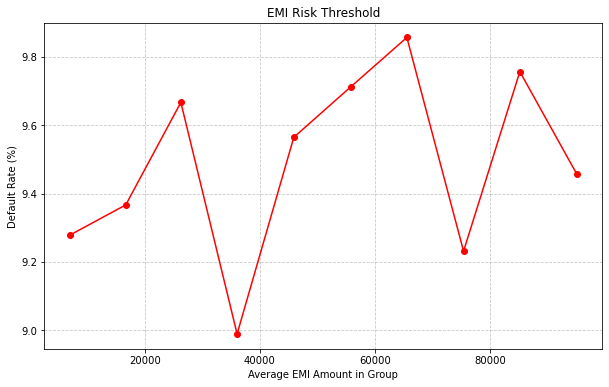

In [36]:
#● Identify thresholds for EMI amounts where defaults are most likely.

# Defaulted
Loan_df['Default_Flag'] = Loan_df['Loan_ID'].isin(Default_df['Loan_ID']).astype(int)

Loan_df['EMI_Decline'] = pd.qcut(Loan_df['EMI_Amount'], 10, labels=False)

threshold_analysis = Loan_df.groupby('EMI_Decline').agg({
    'EMI_Amount': 'mean',
    'Default_Flag': 'mean'
}).reset_index()

# Convert to percentage
threshold_analysis['Default_Rate_%'] = threshold_analysis['Default_Flag'] * 100

plt.figure(figsize=(10, 6))
plt.plot(threshold_analysis['EMI_Amount'], threshold_analysis['Default_Rate_%'], marker='o', linestyle='-', color='red')

plt.title('EMI Risk Threshold')
plt.xlabel('Average EMI Amount in Group')
plt.ylabel('Default Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

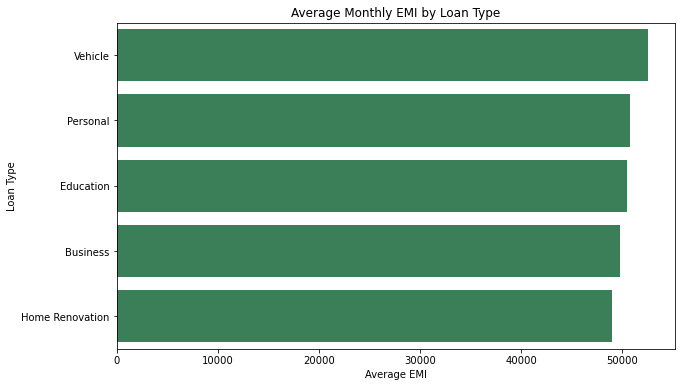

In [37]:
#● Compare EMI trends across loan types.
avg_emi_per_type = merged_data.groupby('Loan_Purpose')['EMI_Amount'].mean().sort_values(ascending=False).reset_index()

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='EMI_Amount', y='Loan_Purpose', data=avg_emi_per_type, color='seagreen')

plt.title('Average Monthly EMI by Loan Type')
plt.xlabel('Average EMI')
plt.ylabel('Loan Type')
plt.show()

# 9. Loan Application Insights

In [38]:
#● Calculate approval and rejection rates for loan applications.

Total_Loans=len(Apps_df)
Total_Loans

Approved_Loans=(Apps_df['Approval_Status']=='Approved').sum()

Rejected_loans=(Apps_df['Approval_Status']=='Rejected').sum()

Approval_rate=(Approved_Loans/Total_Loans)*100
print('The Approval Rate of Loans is:', Approval_rate)


Rejected_rate=(Rejected_loans/Total_Loans)*100
print('The Rejection Rate of Loans is:', Rejected_rate)



#penalty_data = Transaction_df[Transaction_df['Payment_Type'] == 'Penalty'].copy()



The Approval Rate of Loans is: 84.7457627118644
The Rejection Rate of Loans is: 15.254237288135593


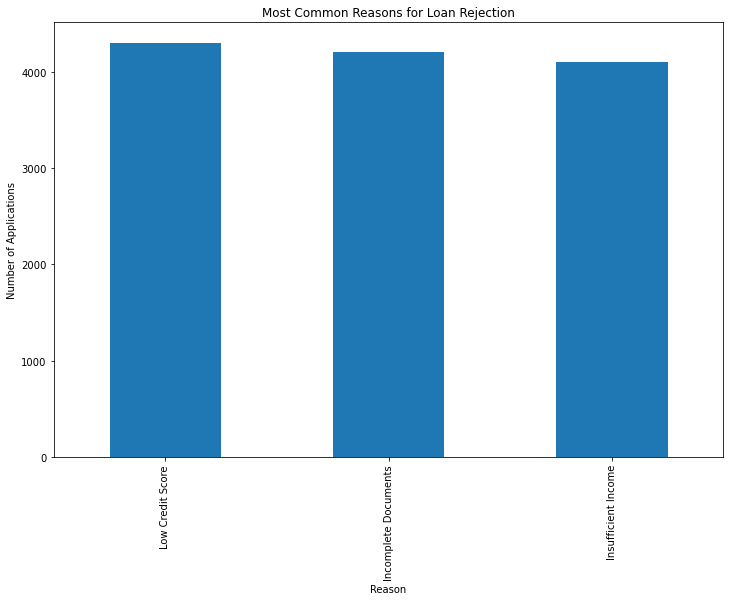

In [39]:
#● Identify the most common reasons for loan rejection.


rejection_counts = Apps_df[Apps_df['Approval_Status'] == 'Rejected']['Rejection_Reason'].value_counts()

rejection_counts.plot(kind='bar', figsize=(12,8))

plt.title('Most Common Reasons for Loan Rejection')
plt.ylabel('Number of Applications')
plt.xlabel('Reason')
plt.show()

# 11. Loan Disbursement Efficiency


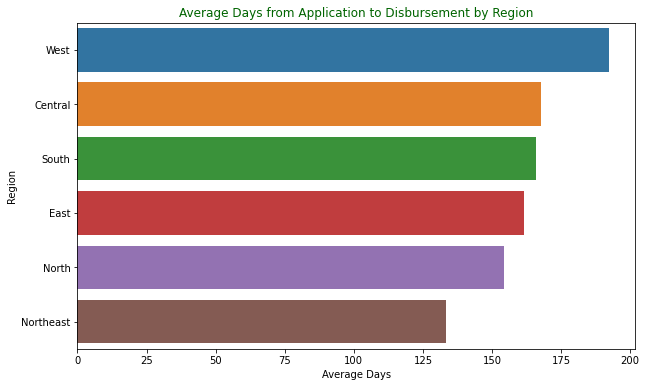

In [75]:
#1Analyze the time from application to loan disbursement and identify bottlenecks.
efficiency_df = pd.merge(merged_data_1[['Loan_ID', 'Application_Date', 'Region', 'Source_Channel']], 
                         Loan_df[['Loan_ID', 'Disbursal_Date']], 
                         on='Loan_ID', how='inner')

efficiency_df['Days_to_Disburse'] = (efficiency_df['Disbursal_Date'] - efficiency_df['Application_Date']).dt.days

bottleneck_report = efficiency_df.groupby('Region')['Days_to_Disburse'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Days_to_Disburse', y='Region', data=bottleneck_report)

plt.title('Average Days from Application to Disbursement by Region', color='darkgreen')
plt.xlabel('Average Days')
plt.show()

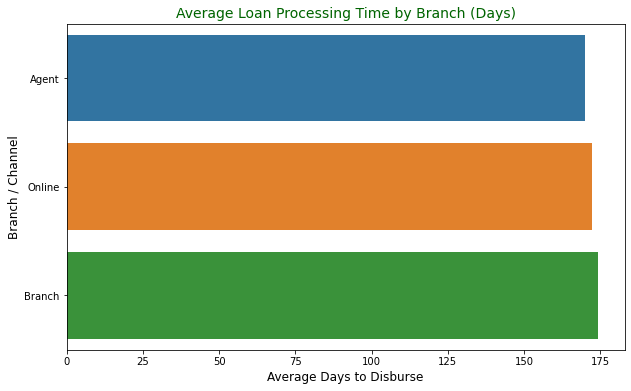

In [73]:
#2 ● Compare average processing times across branches.

merged_data = pd.merge(Apps_df[['Loan_ID', 'Source_Channel', 'Application_Date']], 
                       Loan_df[['Loan_ID', 'Disbursal_Date']], 
                       on='Loan_ID', how='inner')

merged_data['Processing_Time'] = (merged_data['Disbursal_Date'] - merged_data['Application_Date']).dt.days

branch_performance = merged_data.groupby('Source_Channel')['Processing_Time'].mean().sort_values().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Processing_Time', y='Source_Channel', data=branch_performance)

plt.title('Average Loan Processing Time by Branch (Days)', color='darkgreen', fontsize=14)
plt.xlabel('Average Days to Disburse', fontsize=12)
plt.ylabel('Branch / Channel', fontsize=12)
plt.show()

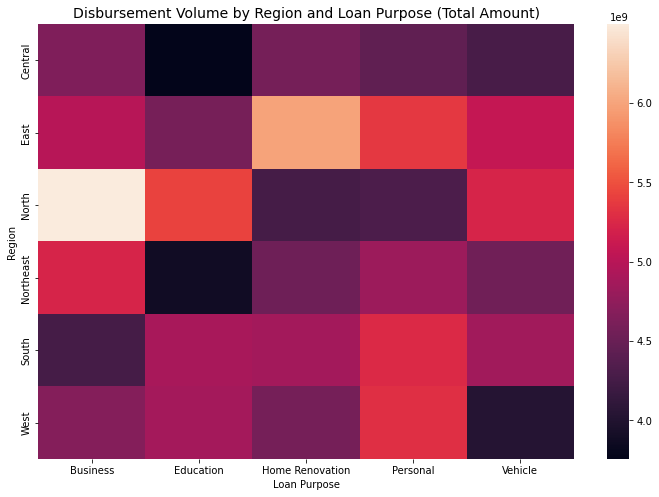

In [82]:
#3Evaluate disbursement trends by loan purpose and region.

master_df = pd.merge(Loan_df[['Loan_ID', 'Loan_Amount' ]], 
                     merged_data_1[['Loan_ID', 'Region','Loan_Purpose']], 
                     on='Loan_ID', how='inner')

disbursement_pivot = master_df.pivot_table(values='Loan_Amount', 
                                          index='Region', 
                                          columns='Loan_Purpose', 
                                          aggfunc='sum')

plt.figure(figsize=(12, 8))
sns.heatmap(disbursement_pivot, annot=False)

plt.title('Disbursement Volume by Region and Loan Purpose (Total Amount)', fontsize=14)
plt.xlabel('Loan Purpose')
plt.ylabel('Region')
plt.show()

# 14 Default Trend

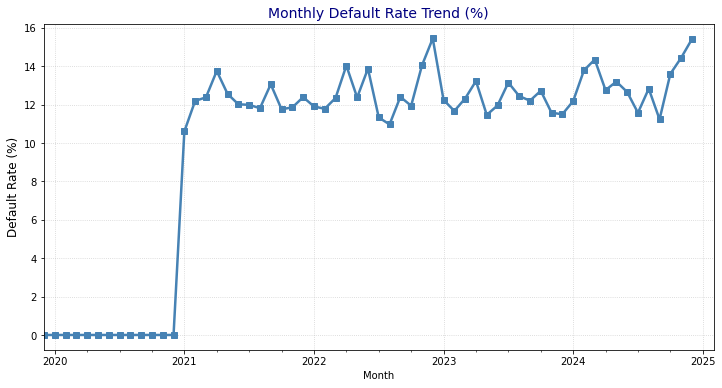

In [80]:
#1. ● Analyze the number of defaults over time to identify patterns.

Loan_df['Month'] = Loan_df['Disbursal_Date'].dt.to_period('M')
Default_df['Month'] = Default_df['Default_Date'].dt.to_period('M')

monthly_loans = Loan_df.groupby('Month').size()
monthly_defaults = Default_df.groupby('Month').size()

trend_df = pd.DataFrame({
    'Total_Loans': monthly_loans,
    'Total_Defaults': monthly_defaults
}).fillna(0)

trend_df['Default_Rate_%'] = (trend_df['Total_Defaults'] / trend_df['Total_Loans']) * 100

plt.figure(figsize=(12, 6))
trend_df['Default_Rate_%'].plot(kind='line', marker='s', color='steelblue', linewidth=2.5)

plt.title('Monthly Default Rate Trend (%)', color='navy', fontsize=14)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

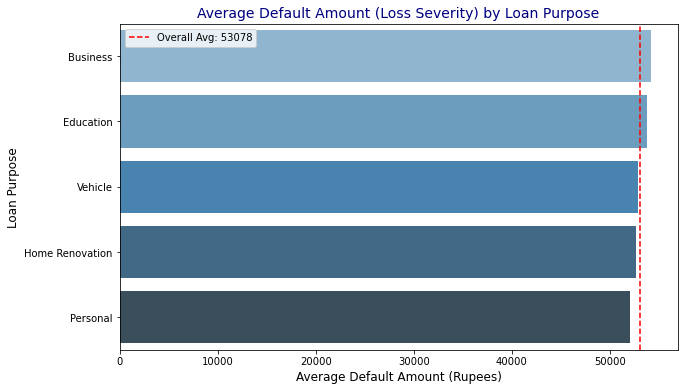

In [87]:
# ● Calculate the average default amount for different loan purposes.

default_analysis_df = pd.merge(Default_df[['Loan_ID', 'Default_Amount']], 
                               merged_data_1[['Loan_ID', 'Loan_Purpose']], 
                               on='Loan_ID', 
                               how='inner')

avg_default_by_purpose = default_analysis_df.groupby('Loan_Purpose')['Default_Amount'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(x='Default_Amount', y='Loan_Purpose', data=avg_default_by_purpose, palette='Blues_d')

plt.title('Average Default Amount (Loss Severity) by Loan Purpose', color='navy', fontsize=14)
plt.xlabel('Average Default Amount (Rupees)', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)

overall_avg = default_analysis_df['Default_Amount'].mean()
plt.axvline(overall_avg, color='red', linestyle='--', label=f'Overall Avg: {overall_avg:.0f}')
plt.legend()

plt.show()

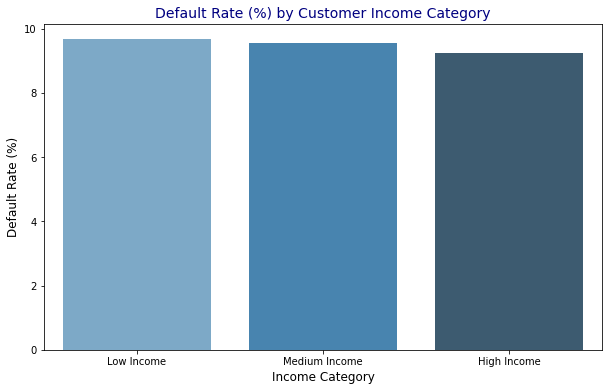

In [93]:
# 3● Compare default rates across customer income categories.
New_master_df = pd.merge(Loan_df, Customer_df[['Customer_ID', 'Annual_Income']], on='Customer_ID', how='left')

New_master_df['Default_Flag'] = New_master_df['Loan_ID'].isin(Default_df['Loan_ID']).astype(int)

def categorize_income(income):
    if income > 1500000: return 'High Income'
    elif income > 500000: return 'Medium Income'
    else: return 'Low Income'

New_master_df['Income_Category'] = New_master_df['Annual_Income'].apply(categorize_income)

income_default_report = New_master_df.groupby('Income_Category')['Default_Flag'].mean().reset_index()
income_default_report['Default_Rate_%'] = income_default_report['Default_Flag'] * 100

order = ['Low Income', 'Medium Income', 'High Income']
income_default_report['Income_Category'] = pd.Categorical(income_default_report['Income_Category'], categories=order, ordered=True)
income_default_report = income_default_report.sort_values('Income_Category')

plt.figure(figsize=(10, 6))
sns.barplot(x='Income_Category', y='Default_Rate_%', data=income_default_report, palette='Blues_d')

plt.title('Default Rate (%) by Customer Income Category', color='navy', fontsize=14)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.xlabel('Income Category', fontsize=12)
plt.show()

# 17. Customer Behavior Analysis

In [120]:
#1.Categorize customers based on their repayment behavior (e.g., always on time, occasional defaulters, frequent defaulters).

Category=pd.merge(Transaction_df,Loan_df, on='Customer_ID')
Category=pd.merge(Category,Default_df, on='Customer_ID')
Category

,Transaction_ID,Loan_ID_x,Customer_ID,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment,Loan_ID_y,...,Default_ID,Loan_ID,Default_Date,Default_Amount,Default_Reason,Recovery_Status,Recovery_Amount,Legal_Action,Recovery_Rate,Month_y
0,T00000017,L014510,C050170,2024-01-11,EMI,20593,0,1669388,UPI,L014510,...,D006972,L050170,2021-11-24,5106,Job Loss,Full,22606,Yes,442.734038,2021-11
1,T00000017,L014510,C050170,2024-01-11,EMI,20593,0,1669388,UPI,L069862,...,D006972,L050170,2021-11-24,5106,Job Loss,Full,22606,Yes,442.734038,2021-11
2,T00066826,L069862,C050170,2022-11-30,EMI,46800,0,456293,IMPS,L014510,...,D006972,L050170,2021-11-24,5106,Job Loss,Full,22606,Yes,442.734038,2021-11
3,T00066826,L069862,C050170,2022-11-30,EMI,46800,0,456293,IMPS,L069862,...,D006972,L050170,2021-11-24,5106,Job Loss,Full,22606,Yes,442.734038,2021-11
4,T00099608,L069862,C050170,2024-06-21,EMI,2878,2896,1738449,NEFT,L014510,...,D006972,L050170,2021-11-24,5106,Job Loss,Full,22606,Yes,442.734038,2021-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112933,T00482019,L036090,C017265,2024-12-13,EMI,32806,1756,43065,IMPS,L036090,...,D002127,L017265,2022-05-05,36728,Medical Emergency,Partial,30781,No,83.807994,2022-05
112934,T00490876,L036090,C017265,2024-08-23,EMI,46773,926,1489647,UPI,L036090,...,D002127,L017265,2022-05-05,36728,Medical Emergency,Partial,30781,No,83.807994,2022-05
112935,T00483831,L055948,C060384,2023-05-21,Penalty,29550,4550,684211,UPI,L055948,...,D008993,L060384,2022-08-17,33618,Business Failure,Partial,7250,Yes,21.565828,2022-08
112936,T00491632,L040761,C066756,2022-04-01,EMI,44387,0,961901,UPI,L040761,...,D003149,L066756,2022-09-05,82005,Other,Full,0,No,0.000000,2022-09


In [121]:
default_counts = Default_df.groupby('Customer_ID').size().reset_index(name='Default_Count')
customer_behavior = pd.merge(Loan_df[['Customer_ID', 'Overdue_Amount']], default_counts, on='Customer_ID', how='left')
customer_behavior['Default_Count'] = customer_behavior['Default_Count'].fillna(0)

In [122]:
def categorize_behavior(row):
    if row['Default_Count'] == 0 and row['Overdue_Amount'] == 0:
        return 'Always on Time'
    elif row['Default_Count'] == 1 or (row['Default_Count'] == 0 and row['Overdue_Amount'] > 0):
        return 'Occasional'
    else:
        return 'Frequent Defaulter'
customer_behavior['Behavior_Category'] = customer_behavior.apply(categorize_behavior, axis=1)

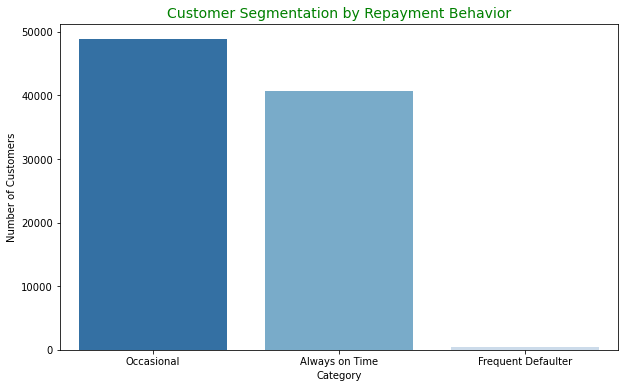

In [123]:
behavior_summary = customer_behavior['Behavior_Category'].value_counts().reset_index()
behavior_summary.columns = ['Category', 'Customer_Count']

# 6. Visualize with a Blue Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Customer_Count', data=behavior_summary, palette='Blues_r')

plt.title('Customer Segmentation by Repayment Behavior', color='Green', fontsize=14)
plt.ylabel('Number of Customers')
plt.show()

,Customer_ID_x,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status,Rejection_Reason,Loan_ID_y,Loan_Amount,...,Recovery_Amount,Legal_Action,Transaction_ID,Customer_ID_y,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment
0,C000019,2020-03-03,2023-10-05,Personal,Agent,5924,Approved,0,L039040,3387057,...,0,Yes,T00009727,C055991,2023-10-05,Penalty,3632,0,1594090,Cheque
1,C000019,2020-03-03,2023-10-05,Personal,Agent,5924,Approved,0,L039040,3387057,...,0,Yes,T00054907,C055991,2021-05-30,EMI,38079,855,1484311,Cheque
2,C000019,2020-03-03,2023-10-05,Personal,Agent,5924,Approved,0,L039040,3387057,...,0,Yes,T00060665,C055991,2023-06-29,Penalty,31260,0,1997008,NEFT
3,C000019,2020-03-03,2023-10-05,Personal,Agent,5924,Approved,0,L039040,3387057,...,0,Yes,T00137750,C055991,2023-02-25,EMI,38023,2853,1743973,Cheque
4,C000019,2020-03-03,2023-10-05,Personal,Agent,5924,Approved,0,L039040,3387057,...,0,Yes,T00193074,C055991,2024-07-17,EMI,1471,0,979276,UPI


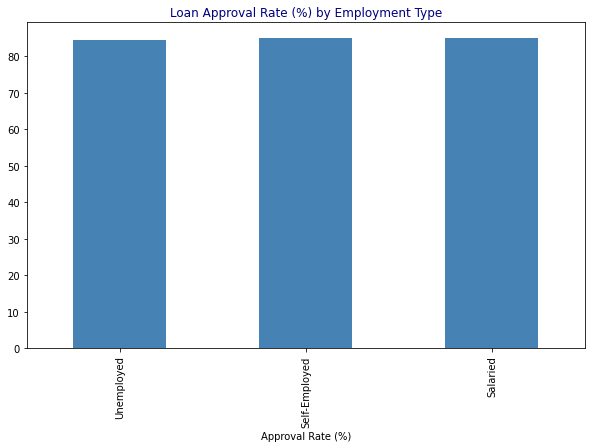

In [136]:
# 2. Merge to link demographics with approval status
Approval = pd.merge(Apps_df[['Customer_ID', 'Approval_Status', 'Rejection_Reason']], 
                         Customer_df[['Customer_ID', 'Employment_Status', 'Annual_Income']], 
                         on='Customer_ID', how='left')

# 3. Calculate Approval Rate (%)
approval_stats = Approval.groupby('Employment_Status')['Approval_Status'].value_counts(normalize=True).unstack() * 100

# 4. Plotting (Blue Theme)
approval_stats['Approved'].sort_values().plot(kind='bar', color='steelblue', figsize=(10, 6))
plt.title('Loan Approval Rate (%) by Employment Type', color='navy')
plt.xlabel('Approval Rate (%)')
plt.show()

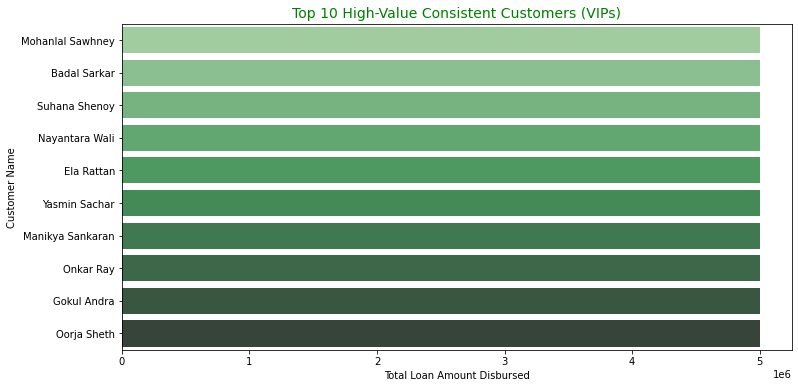

In [143]:
#3. ● Identify high-value customers with consistent repayment histories.
defaulter_ids = Default_df['Customer_ID'].unique()
consistent_payers = Loan_df[~Loan_df['Customer_ID'].isin(defaulter_ids)]


clean_payers = consistent_payers[consistent_payers['Overdue_Amount'] == 0]

threshold = clean_payers['Loan_Amount'].quantile(0.75)
high_value_consistent = clean_payers[clean_payers['Loan_Amount'] >= threshold]

vip_list = pd.merge(high_value_consistent, Customer_df[['Customer_ID', 'Full_Name']], 
                    on='Customer_ID', how='left')

top_10_vips = vip_list.sort_values(by='Loan_Amount', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Loan_Amount', y='Full_Name', data=top_10_vips, palette='Greens_d')

plt.title('Top 10 High-Value Consistent Customers (VIPs)', color='green', fontsize=14)
plt.xlabel('Total Loan Amount Disbursed')
plt.ylabel('Customer Name')
plt.show()